In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [2]:
df = pd.read_csv('modified_synthetic_economic_data.csv')

In [3]:
df.head()

,year,month,interest_rate,unemployment_rate,index_price
0,1924,1,3.50,5.19,534.714897
1,1925,1,2.86,4.36,424.911412
2,1926,1,3.65,5.18,582.253910
3,1927,1,4.52,5.81,784.797318
4,1928,1,2.77,5.07,321.169866


In [5]:
df.drop(columns=['year','month'], inplace=True)

In [6]:
df.head()

,interest_rate,unemployment_rate,index_price
0,3.50,5.19,534.714897
1,2.86,4.36,424.911412
2,3.65,5.18,582.253910
3,4.52,5.81,784.797318
4,2.77,5.07,321.169866


In [7]:
df.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,0.014553,0.890899
unemployment_rate,0.014553,1.000000,-0.441184
index_price,0.890899,-0.441184,1.000000


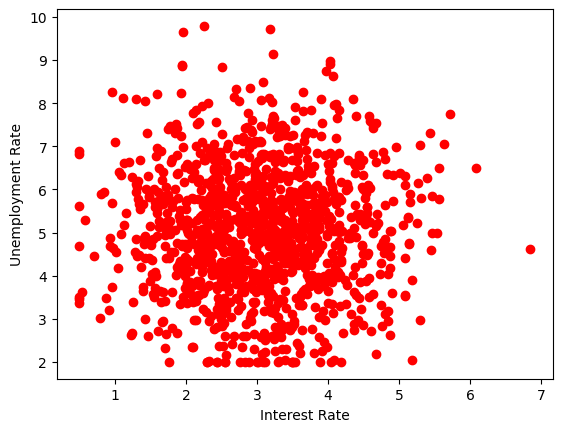

In [12]:
plt.scatter(df['interest_rate'], df['unemployment_rate'], color='r')
plt.xlabel("Interest Rate")
plt.ylabel("Unemployment Rate")
plt.show()

In [13]:
df.head()

,interest_rate,unemployment_rate,index_price
0,3.50,5.19,534.714897
1,2.86,4.36,424.911412
2,3.65,5.18,582.253910
3,4.52,5.81,784.797318
4,2.77,5.07,321.169866


In [18]:
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [19]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [20]:
import seaborn as sns

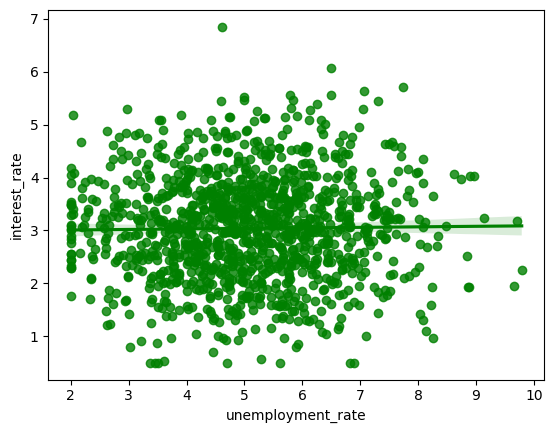

In [25]:
sns.regplot(data=df, x='unemployment_rate', y='interest_rate', color='g')
plt.show()

In [26]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [27]:
X_test

array([[-1.06408997, -0.45411332],
       [-0.44021897, -0.62671436],
       [-0.47141252,  1.00263942],
       [-0.09708992, -1.13070938],
       [ 0.30842622, -0.75789115],
       [ 1.11945852,  0.42960398],
       [ 2.13844781, -1.02024472],
       [-0.50260607, -0.88906793],
       [-1.19926202, -1.64160845],
       [-0.62738027, -0.87525985],
       [-0.57539102,  0.03607362],
       [-1.57358462, -0.69575477],
       [-1.86472441, -1.63470441],
       [-0.58578887,  0.1327302 ],
       [-0.85613297,  0.65743734],
       [-0.96011147, -0.20556783],
       [ 0.55797462,  0.60910905],
       [-0.76255232,  0.06368978],
       [ 0.98428647, -0.05367892],
       [ 0.97388862, -0.7164669 ],
       [-0.90812222,  0.18105849],
       [ 1.52497467,  0.89907879],
       [-1.18886417, -0.60600224],
       [-0.52340177, -0.64742648],
       [-0.10748777,  0.46412418],
       [-0.65857382,  0.40889185],
       [ 1.78492092, -0.24008804],
       [-0.01390712,  0.02226553],
       [ 0.29802837,

In [28]:
from sklearn.linear_model import LinearRegression
regression = LinearRegression()

In [29]:
regression.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[ 298.17,-154.68]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,406.4
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,2
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](2,)","[31.06,30.91]"


In [33]:
y_pred = regression.predict(X_test)

In [34]:
y_pred

array([ 159.35563434,  372.07141322,  110.74119347,  552.3394048 ,
        615.58321799,  673.72390689, 1201.81629762,  394.0506317 ,
        302.73418157,  354.71123862,  229.24715979,   44.81836469,
        103.24732049,  211.19597127,   49.42628858,  151.91344142,
        478.54198276,  169.17014927,  708.17452252,  807.59463278,
        107.61135084,  722.0168275 ,  145.64634281,  350.47280839,
        302.54938143,  146.77706377,  975.73117417,  398.79898236,
        260.06902571,   91.72555082,  292.98246671,  945.42293535,
        134.65673357,  554.5047933 ,  686.34685082,  367.62604948,
        408.95344424,  336.54546335,  493.18247507,  507.52368712,
       -138.31714929,  453.84678865,  122.42181663,   31.30859334,
        353.43267755,  208.56863574,  430.18255542, -106.37928244,
        469.38893505,  878.04415869,  629.14837607,  605.86104982,
        320.94422356,  301.76602076,  444.40547405,  373.61600119,
        400.21426355,  405.44669462,  716.27076933,  268.99300

In [35]:
y_test

1178    159.248741
865     371.950571
101     110.873123
439     552.119852
58      615.362753
           ...    
382     -95.080739
867     523.687360
542     552.597520
1193    603.698059
874     489.845249
Name: index_price, Length: 240, dtype: float64

In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

In [37]:
print(mse)
print(mae)
print(rmse)

0.3447812768967113
0.2230228065324707
0.5871807872339756


In [38]:
from sklearn.metrics import r2_score
score = r2_score(y_test, y_pred)

In [39]:
print(score)

0.9999972923940825


In [41]:
residuals = y_pred - y_test
residuals

1178    0.106894
865     0.120842
101    -0.131930
439     0.219553
58      0.220465
          ...   
382     0.215813
867     0.054661
542     0.044872
1193    0.241496
874     0.244343
Name: index_price, Length: 240, dtype: float64

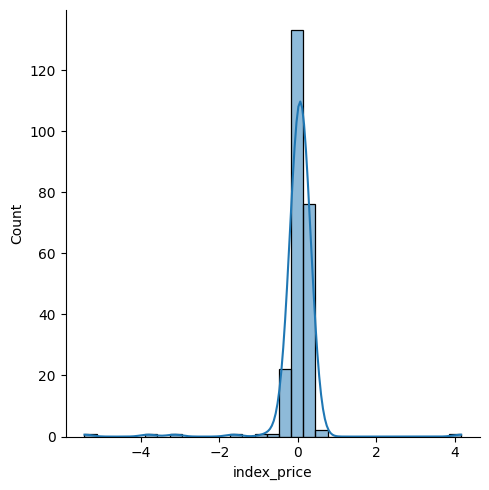

In [42]:
sns.displot(residuals, kde=True)

In [43]:
import joblib

In [44]:
joblib.dump(regression, 'mlr.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [45]:
regression_loaded = joblib.load('mlr.pkl')
scaler_loaded = joblib.load('scaler.pkl')

In [47]:
predicted_value = regression_loaded.predict(scaler_loaded.transform([[150, 340]]))

/Users/nayan/ml/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [49]:
predicted_value[0]

np.float64(10199.074078391559)